# House Price Prediction 

## Task 1 : Data Loading & Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('Housing.csv')
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [2]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 545
Columns: 13


**Target variable:** `price` : the value the model is trying to predict.

**Feature variables:** the remaining 12 columns : `area`, `bedrooms`, `bathrooms`, `stories`, `mainroad`, `guestroom`, `basement`, `hotwaterheating`, `airconditioning`, `parking`, `prefarea`, and `furnishingstatus`.

In [3]:
df.dtypes

price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object

In [4]:
missing = df.isnull().sum()
print("Missing values per column:")
missing

Missing values per column:


price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

## Task 2 : Data Cleaning

In [5]:
print("Missing values before cleaning:", df.isnull().sum().sum())
df = df.dropna()  # drop any rows with missing values (kept for robustness, even though none were found)

print("Duplicate rows before cleaning:", df.duplicated().sum())
df = df.drop_duplicates()

print("Shape after cleaning:", df.shape)

Missing values before cleaning: 0
Duplicate rows before cleaning: 0
Shape after cleaning: (545, 13)


In [6]:
# Convert yes/no and categorical columns into numeric form using one-hot encoding
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
categorical_cols = binary_cols + ['furnishingstatus']

df_clean = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
df_clean.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


All 12 original features were kept. In this dataset each one is plausibly linked to price , size and room counts capture space, `mainroad`/`prefarea`/`furnishingstatus` capture location and presentation, and the remaining yes/no columns capture amenities , so nothing was dropped at this stage.

## Task 3 : Model Building

In [7]:
X = df_clean.drop('price', axis=1)
y = df_clean['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training rows: {X_train.shape[0]}")
print(f"Test rows: {X_test.shape[0]}")

Training rows: 436
Test rows: 109


In [8]:
# --- Linear Regression ---
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

print(f"Linear Regression -> MAE: {lr_mae:,.0f} | RMSE: {lr_rmse:,.0f} | R²: {lr_r2:.4f}")

Linear Regression -> MAE: 970,043 | RMSE: 1,324,507 | R²: 0.6529


In [9]:
# --- Random Forest Regressor ---
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print(f"Random Forest -> MAE: {rf_mae:,.0f} | RMSE: {rf_rmse:,.0f} | R²: {rf_r2:.4f}")

Random Forest -> MAE: 1,021,546 | RMSE: 1,400,566 | R²: 0.6119


In [10]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [lr_mae, rf_mae],
    'RMSE': [lr_rmse, rf_rmse],
    'R² Score': [lr_r2, rf_r2]
})
comparison

,Model,MAE,RMSE,R² Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.021546e+06,1.400566e+06,0.611919


In [12]:
#Prediction
new_house = pd.DataFrame([{
    'area': 6000, 'bedrooms': 3, 'bathrooms': 2, 'stories': 2,
    'mainroad': 'yes', 'guestroom': 'no', 'basement': 'yes',
    'hotwaterheating': 'no', 'airconditioning': 'yes',
    'parking': 1, 'prefarea': 'yes', 'furnishingstatus': 'semi-furnished'
}])

new_house_encoded = pd.get_dummies(new_house, columns=categorical_cols, drop_first=True)
new_house_encoded = new_house_encoded.reindex(columns=X.columns, fill_value=0)  # match training columns exactly

print("Linear Regression:", lr_model.predict(new_house_encoded)[0])
print("Random Forest:", rf_model.predict(new_house_encoded)[0])

Linear Regression: 5134865.965206563
Random Forest: 6686925.0


**Comparison:** Linear Regression edges out Random Forest on this test split (higher R², lower MAE/RMSE). With only 545 houses total, the tree ensemble has relatively little data to learn from, while price here scales fairly linearly with the strongest features (area, bathrooms) : which favors the simpler model.

## Task 4 : Visualization

In [11]:
os.makedirs('charts', exist_ok=True)

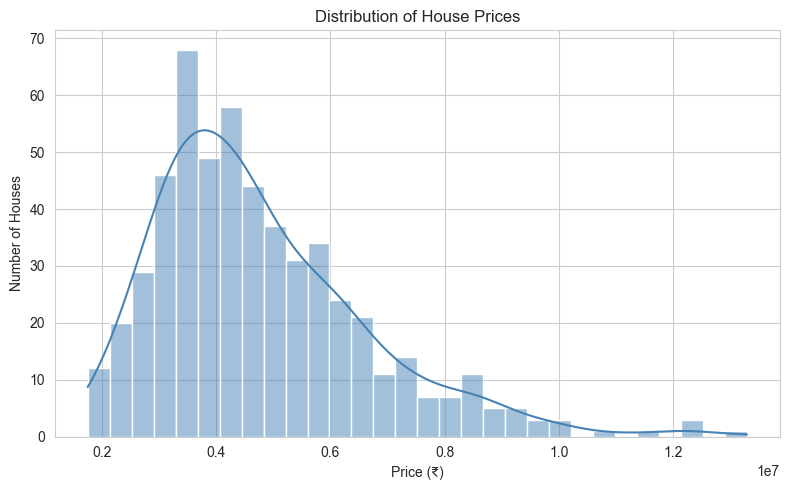

In [17]:
# Chart 1: Distribution of house prices
plt.figure(figsize=(8, 5))
sns.histplot(df['price'], bins=30, kde=True, color='steelblue')
plt.title('Distribution of House Prices')
plt.xlabel('Price (₹)')
plt.ylabel('Number of Houses')
plt.tight_layout()
plt.savefig('charts/chart1_price_distribution.png', dpi=150)
plt.show()

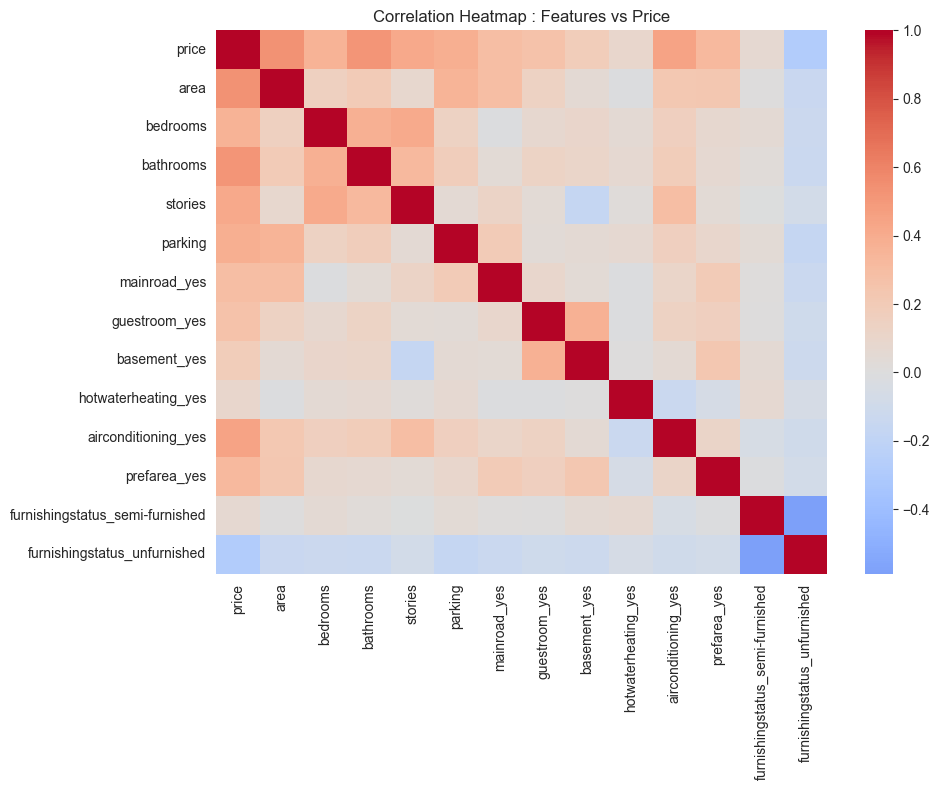

In [16]:
# Chart 2: Correlation heatmap
plt.figure(figsize=(10, 8))
corr = df_clean.corr()
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap : Features vs Price')
plt.tight_layout()
plt.savefig('charts/chart2_correlation_heatmap.png', dpi=150)
plt.show()

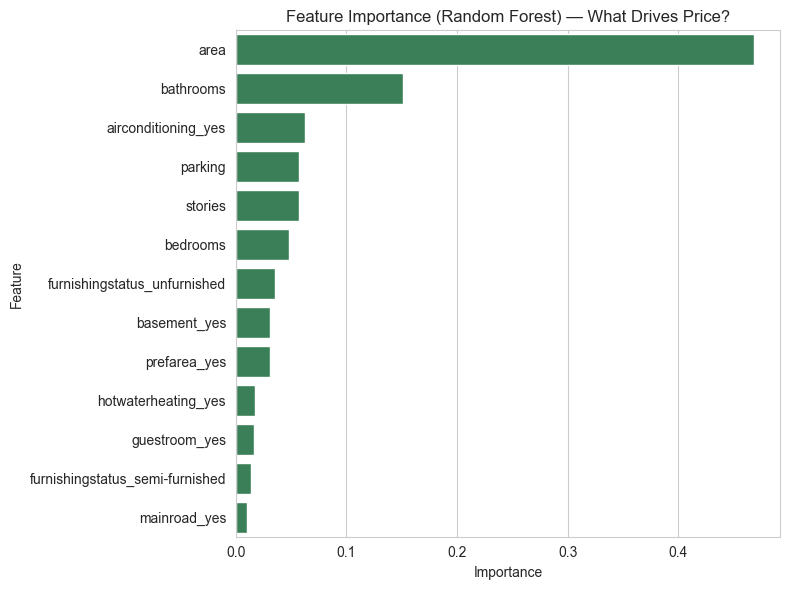

In [15]:
# Chart 3 (creative): Random Forest feature importance :
# directly answers "which features influence price most?"
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index, color='seagreen')
plt.title('Feature Importance (Random Forest) — What Drives Price?')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('charts/chart3_feature_importance.png', dpi=150)
plt.show()

## Task 5 — Insights & Summary

Area and number of bathrooms turned out to be the strongest predictors of price , they dominate both the correlation table and the Random Forest's feature importance, with air conditioning, number of stories, and parking close behind.

The Linear Regression model explains about 65% of the variation in price (R² = 0.65) on houses it hadn't seen before, with typical predictions landing within roughly ₹9.7 lakh of the actual price , a solid first-pass estimate, though not precise enough to replace an in-person appraisal.

The average prediction is off by about ₹9.7 lakh (the MAE)  and since the typical house in this dataset sells for around ₹43 lakh, that's an average miss of roughly 21–22% of the price. So if the model says a house is worth ₹50 lakh, the real price is plausibly anywhere from about ₹40 to ₹60 lakh. That's useful as a quick ballpark , good enough to flag if a listing looks way overpriced or underpriced  but not precise enough to replace an actual site visit or appraisal.

What surprised me most was that Random Forest, often assumed to be the stronger model, actually slightly underperformed plain Linear Regression here (R² 0.61 vs 0.65); with only 545 houses to learn from, the tree ensemble seems to overfit a little while price scales fairly linearly with area and bathrooms.


One actionable takeaway for a real estate business: since unfurnished status is one of the few features that visibly drags price down, even lightly staging or furnishing a property before listing it looks like a low-cost way to lift its perceived value.